In [53]:
import pandas as pd

df_labels = pd.read_csv("dataset_labels.csv")
df_labels

,file_path,filename,is_doc_id,id_doc_type,doc_type
0,dataset/false_doc,12031810-405818722.jpg,False,NaN,NaN
1,dataset/false_doc,facture-d-avoir-exemple-744x1024-2687424784.jpg,False,NaN,NaN
2,dataset/false_id,1-18900169.jpg,False,NaN,NaN
3,dataset/false_id,1-842369233.jpg,False,NaN,NaN
4,dataset/false_id,Document-d-identite-2.jpg,False,NaN,NaN
5,dataset/false_id,ID_passport_USA-2021-497107151.jpg,False,NaN,NaN
6,dataset/false_id,IMG_6211_LegalPhoto-1697863245.jpg,False,NaN,NaN
7,dataset/false_id,carte-d-identite-ce-qui-change-en-bretagne_317...,False,NaN,NaN
8,dataset/false_id,csm_CA_RPC_2021_1920_4c0a2d9287-515808575.jpg,False,NaN,NaN
9,dataset/false_id,les-faux-papiers-ne-sont-pas-toujours-facileme...,False,NaN,NaN


In [54]:
df_results = pd.read_csv("results.csv", sep=";")
df_results

,file_path,filename,mistral_is_doc_id,mistral_id_doc_type,mistral_doc_type,azure_is_doc_id,azure_id_doc_type,azure_doc_type,mistral_vision_is_doc_id,mistral_vision_id_doc_type,mistral_vision_doc_type,azure_vision_is_doc_id,azure_vision_id_doc_type,azure_vision_doc_type,aligned
0,dataset/false_doc,12031810-405818722.jpg,True,proof_of_residency,administrative document,NaN,NaN,NaN,True,proof_of_residency,letter_requesting_vehicle_registration_documents,False,not_identity_doc,administrative request letter,False
1,dataset/false_doc,facture-d-avoir-exemple-744x1024-2687424784.jpg,False,not_identity_doc,credit_note,NaN,NaN,NaN,False,not_identity_doc,credit_note,False,not_identity_doc,credit note,False
2,dataset/false_id,1-18900169.jpg,True,id card,identity card,NaN,NaN,NaN,True,id card,"[{'name': 'Student ID Card', 'issuer': 'Univer...",True,id card,"student_id, voter_id",False
3,dataset/false_id,1-842369233.jpg,True,proof_of_residency,residence_permit,NaN,NaN,NaN,True,proof_of_residency,Titre de Séjour (French Residence Permit),True,proof_of_residency,titre de séjour,False
4,dataset/false_id,Document-d-identite-2.jpg,True,passport,passport,NaN,NaN,NaN,True,passport,travel_document,True,passport,passport,False
5,dataset/false_id,ID_passport_USA-2021-497107151.jpg,True,passport,passport,NaN,NaN,NaN,True,passport,United States of America Passport,True,passport,passport,False
6,dataset/false_id,IMG_6211_LegalPhoto-1697863245.jpg,True,id card,identity document,NaN,NaN,NaN,True,id card,Legal Identity Photo Print (conforming to ISO/...,True,not_identity_doc,passport_photo_sheet,False
7,dataset/false_id,carte-d-identite-ce-qui-change-en-bretagne_317...,True,id card,identity document,NaN,NaN,NaN,True,id_card,Carte Nationale d’Identité (French National Id...,True,id card,French national identity card,False
8,dataset/false_id,csm_CA_RPC_2021_1920_4c0a2d9287-515808575.jpg,True,proof_of_residency,permanent_resident_card,NaN,NaN,NaN,True,id card,Permanent Resident Card,True,proof_of_residency,permanent_resident_card,False
9,dataset/false_id,les-faux-papiers-ne-sont-pas-toujours-facileme...,True,id card,identity card,NaN,NaN,NaN,True,id_card,Italian Identity Card (Carta d’Identità) and D...,True,id card,"passport, id card, driving license",False


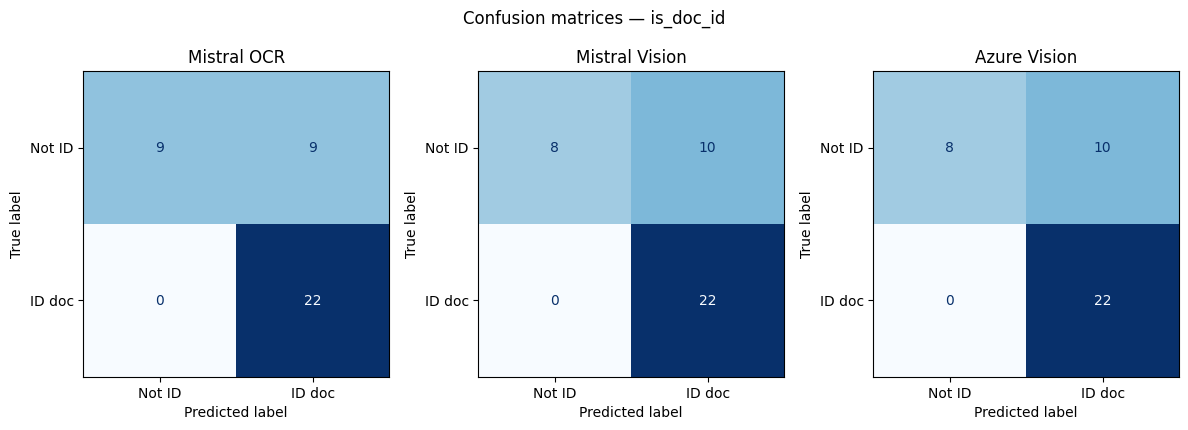

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

MODELS = {
    "Mistral OCR":    "mistral_is_doc_id",
    "Azure CU":       "azure_is_doc_id",
    "Mistral Vision": "mistral_vision_is_doc_id",
    "Azure Vision":   "azure_vision_is_doc_id",
}
BOOL_MAP = {True: 1, False: 0, "True": 1, "False": 0}

merged = df_labels[["filename", "is_doc_id"]].merge(df_results, on="filename", suffixes=("_gt", ""))
merged = merged.dropna(subset=["is_doc_id"])


def get_yt_ys(col):
    """Return (y_true, y_score) for a given model column, excluding missing predictions."""
    mask = merged[col].notna() & (merged[col] != "")
    y_t = merged.loc[mask, "is_doc_id"].astype(bool).astype(int)
    y_s = merged.loc[mask, col].map(BOOL_MAP).fillna(0).astype(int)
    return y_t, y_s


active = {name: col for name, col in MODELS.items() if len(get_yt_ys(col)[0]) > 0 and get_yt_ys(col)[0].nunique() == 2}

fig, axes = plt.subplots(1, len(active), figsize=(4 * len(active), 4))
if len(active) == 1:
    axes = [axes]

for ax, (name, col) in zip(axes, active.items()):
    y_t, y_s = get_yt_ys(col)
    cm = confusion_matrix(y_t, y_s)
    ConfusionMatrixDisplay(cm, display_labels=["Not ID", "ID doc"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion matrices — is_doc_id", y=1.02)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score

rows = []
for name, col in MODELS.items():
    y_t, y_s = get_yt_ys(col)
    if len(y_t) == 0 or y_t.nunique() < 2:
        continue
    rows.append({
        "model":     name,
        "n":         len(y_t),
        "accuracy":  accuracy_score(y_t, y_s),
        "precision": precision_score(y_t, y_s, zero_division=0),
        "recall":    recall_score(y_t, y_s, zero_division=0),
        "f1":        f1_score(y_t, y_s, zero_division=0),
        "mcc":       matthews_corrcoef(y_t, y_s),
    })

(pd.DataFrame(rows)
   .set_index("model")
   .style
   .format("{:.2f}", subset=["accuracy", "precision", "recall", "f1", "mcc"])
   .background_gradient(cmap="RdYlGn", subset=["accuracy", "precision", "recall", "f1", "mcc"])
)

,n,accuracy,precision,recall,f1,mcc
model,,,,,,
Mistral OCR,40,0.78,0.71,1.00,0.83,0.60
Mistral Vision,40,0.75,0.69,1.00,0.81,0.55
Azure Vision,40,0.75,0.69,1.00,0.81,0.55


## Conclusion — Performance des modèles sur `is_doc_id`

L'analyse porte sur **40 fichiers** labellisés (22 documents d'identité, 18 non-identité), évalués sur trois modèles disposant de résultats complets. Azure CU n'a produit aucune prédiction et est exclu.

> **Note méthodologique** — ROC AUC n'est pas utilisé ici : il requiert des scores de confiance continus pour faire varier un seuil. Avec des sorties booléennes, la "courbe" ROC se réduit à un unique point et l'AUC est équivalente à la balanced accuracy, sans apport supplémentaire. Les matrices de confusion et les métriques F1/MCC sont plus adaptées.

### Résultats

| Modèle | Accuracy | Precision | Recall | F1 | MCC |
|---|---|---|---|---|---|
| **Mistral OCR** | **0.78** | **0.71** | **1.00** | **0.83** | **0.60** |
| Mistral Vision | 0.75 | 0.69 | 1.00 | 0.81 | 0.55 |
| Azure Vision | 0.75 | 0.69 | 1.00 | 0.81 | 0.55 |

### Points clés

**Recall parfait (1.00) sur les trois modèles** — aucun document d'identité réel n'est manqué. C'est la propriété la plus critique en vérification documentaire : un faux négatif représente un risque métier majeur.

**Mistral OCR est le meilleur modèle** (F1 = 0.83, MCC = 0.60), devant Mistral Vision et Azure Vision à égalité (F1 = 0.81, MCC = 0.55). L'écart est faible, ce qui suggère que l'OCR n'apporte pas d'avantage décisif sur la vision pure pour cette tâche.

**Precision modérée (~0.69–0.71)** — 9 à 10 faux positifs sur 40 fichiers, tous issus de la catégorie `false_id` (photos de documents sur Internet). Cette catégorie est intrinsèquement ambiguë pour les modèles.

**MCC entre 0.55 et 0.60** — performance correcte mais en deçà du seuil recommandé pour la production (> 0.80).

### Limites

- **Dataset petit** (n=40) — les métriques sont sensibles à 1 ou 2 exemples.
- **Azure CU non évalué** — à relancer.
- **`false_id` ambiguë** — images de documents web, pas des faux documents réels.

### Recommandations

1. **Étendre le dataset** avec plus de cas négatifs réels pour réduire les faux positifs.
2. **Relancer Azure CU** pour la comparaison complète sur 4 modèles.
3. **Exploiter `id_doc_type`** comme filtre secondaire pour affiner la décision au-delà du booléen.

## Métriques d'évaluation — rappel

| Métrique | Formule | Ce qu'elle mesure | Plage | Objectif | Quand l'utiliser |
|---|---|---|---|---|---|
| **Accuracy** | (TP + TN) / Total | Part des prédictions correctes (toutes classes) | [0, 1] | → 1 | Classes équilibrées |
| **Precision** | TP / (TP + FP) | Parmi les positifs prédits, combien sont vrais | [0, 1] | → 1 | Coût élevé des faux positifs |
| **Recall** | TP / (TP + FN) | Parmi les vrais positifs, combien sont détectés | [0, 1] | → 1 | Coût élevé des faux négatifs |
| **F1** | 2 × (P × R) / (P + R) | Moyenne harmonique Precision/Recall | [0, 1] | → 1 | Classes déséquilibrées |
| **MCC** | (TP·TN − FP·FN) / √(...) | Corrélation entre prédictions et réalité | [−1, 1] | → 1 | Déséquilibre sévère, vision globale |

> **Légende :** TP = vrai positif · TN = vrai négatif · FP = faux positif · FN = faux négatif
> **Valeurs de référence MCC :** −1 = prédictions systématiquement inverses · 0 = aléatoire · +1 = parfait

### Règles d'or
- **Accuracy** trompe sur des classes déséquilibrées (ex : 95% de classe majoritaire).
- **Precision vs Recall** : arbitrage selon le coût métier de chaque type d'erreur.
- **F1** synthétise les deux, mais suppose que Precision et Recall ont le même poids.
- **MCC** est le seul indicateur symétrique sur toutes les cases de la matrice de confusion — privilégié en contexte médical, fraud detection, KYC/AML.